# Anthony Wolfe Notebook for Census Bureau Exploration

#### Note: Worked with Jonathan and others but notebooks kept separate for productivity

In [82]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np

In [83]:
all_df = pd.read_csv('../data/all-ages.csv')

In [84]:
all_df.head().sort_values("Major_code")

,index,Major_code,Major,Major_category,Total,Employed,Employed_full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th
0,0,1100,GENERAL AGRICULTURE,Agriculture & Natural Resources,128148,90245,74078,2423,0.026147,50000,34000,80000.0
1,1,1101,AGRICULTURE PRODUCTION AND MANAGEMENT,Agriculture & Natural Resources,95326,76865,64240,2266,0.028636,54000,36000,80000.0
2,2,1102,AGRICULTURAL ECONOMICS,Agriculture & Natural Resources,33955,26321,22810,821,0.030248,63000,40000,98000.0
3,3,1103,ANIMAL SCIENCES,Agriculture & Natural Resources,103549,81177,64937,3619,0.042679,46000,30000,72000.0
4,4,1104,FOOD SCIENCE,Agriculture & Natural Resources,24280,17281,12722,894,0.049188,62000,38500,90000.0


In [85]:
all_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          173 non-null    int64  
 1   Major_code                     173 non-null    int64  
 2   Major                          173 non-null    str    
 3   Major_category                 173 non-null    str    
 4   Total                          173 non-null    int64  
 5   Employed                       173 non-null    int64  
 6   Employed_full_time_year_round  173 non-null    int64  
 7   Unemployed                     173 non-null    int64  
 8   Unemployment_rate              173 non-null    float64
 9   Median                         173 non-null    int64  
 10  P25th                          173 non-null    int64  
 11  P75th                          173 non-null    float64
dtypes: float64(2), int64(8), str(2)
memory usage: 16.3 KB


In [86]:
all_df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,173.0,86.000000,50.084928,0.0,43.000000,86.000000,129.000000,1.720000e+02
Major_code,173.0,3879.815029,1687.753140,1100.0,2403.000000,3608.000000,5503.000000,6.403000e+03
Total,173.0,230256.635838,422068.483149,2396.0,24280.000000,75791.000000,205763.000000,3.123510e+06
Employed,173.0,166161.982659,307324.399668,1492.0,17281.000000,56564.000000,142879.000000,2.354398e+06
Employed_full_time_year_round,173.0,126307.774566,242425.389073,1093.0,12722.000000,39613.000000,111025.000000,1.939384e+06
Unemployed,173.0,9725.034682,18022.040192,0.0,1101.000000,3619.000000,8862.000000,1.472610e+05
Unemployment_rate,173.0,0.057355,0.019177,0.0,0.046261,0.054719,0.069043,1.561475e-01
Median,173.0,56816.184971,14706.226865,35000.0,46000.000000,53000.000000,65000.000000,1.250000e+05
P25th,173.0,38697.109827,9414.524761,24900.0,32000.000000,36000.000000,42000.000000,7.800000e+04
P75th,173.0,82506.358382,20805.330126,45800.0,70000.000000,80000.000000,95000.000000,2.100000e+05


In [87]:
# Major category specific numeric-only table for grouping logic

num_cols_list = all_df.select_dtypes(include="number").columns.to_list()
#num_cols_list.append("Major")
num_cols_list.append("Major_category")
num_cols_list.remove("index")
num_cols_list.append("Major_code")
all_df_num = all_df[num_cols_list]
#all_df_num.groupby(by="Major").mean().sort_values("Major_code")
all_df_num.head()

,Major_code,Total,Employed,Employed_full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,Major_category,Major_code
0,1100,128148,90245,74078,2423,0.026147,50000,34000,80000.0,Agriculture & Natural Resources,1100
1,1101,95326,76865,64240,2266,0.028636,54000,36000,80000.0,Agriculture & Natural Resources,1101
2,1102,33955,26321,22810,821,0.030248,63000,40000,98000.0,Agriculture & Natural Resources,1102
3,1103,103549,81177,64937,3619,0.042679,46000,30000,72000.0,Agriculture & Natural Resources,1103
4,1104,24280,17281,12722,894,0.049188,62000,38500,90000.0,Agriculture & Natural Resources,1104


In [88]:
all_df_num.groupby("Major_category").mean().round(0)

,Major_code,Total,Employed,Employed_full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,Major_code
Major_category,,,,,,,,,,
Agriculture & Natural Resources,1152.0,63244.0,48042.0,38919.0,1855.0,0.0,55000.0,36550.0,81300.0,1152.0
Arts,6015.0,225733.0,163587.0,106826.0,13016.0,0.0,43525.0,29112.0,64500.0,6015.0
Biology & Life Science,3476.0,95585.0,67647.0,48752.0,4095.0,0.0,50821.0,33214.0,78771.0,3476.0
Business,6213.0,758365.0,579219.0,474717.0,33415.0,0.0,60615.0,41854.0,91462.0,6213.0
Communications & Journalism,1902.0,450956.0,355760.0,267047.0,25300.0,0.0,49500.0,34000.0,76250.0,1902.0
Computers & Mathematics,2703.0,161943.0,128237.0,106380.0,7270.0,0.0,66273.0,43427.0,95818.0,2703.0
Education,2388.0,293757.0,177075.0,116694.0,7834.0,0.0,43831.0,33222.0,58456.0,2388.0
Engineering,2490.0,123311.0,90413.0,76414.0,5048.0,0.0,77759.0,52459.0,108534.0,2490.0
Health,5938.0,245905.0,182724.0,127926.0,6251.0,0.0,56458.0,40067.0,77500.0,5938.0


In [89]:
major_cat_groups = all_df_num.groupby("Major_category").mean().round(0)

In [90]:
major_cat_groups.convert_dtypes()

,Major_code,Total,Employed,Employed_full_time_year_round,Unemployed,Unemployment_rate,Median,P25th,P75th,Major_code
Major_category,,,,,,,,,,
Agriculture & Natural Resources,1152,63244,48042,38919,1855,0,55000,36550,81300,1152
Arts,6015,225733,163587,106826,13016,0,43525,29112,64500,6015
Biology & Life Science,3476,95585,67647,48752,4095,0,50821,33214,78771,3476
Business,6213,758365,579219,474717,33415,0,60615,41854,91462,6213
Communications & Journalism,1902,450956,355760,267047,25300,0,49500,34000,76250,1902
Computers & Mathematics,2703,161943,128237,106380,7270,0,66273,43427,95818,2703
Education,2388,293757,177075,116694,7834,0,43831,33222,58456,2388
Engineering,2490,123311,90413,76414,5048,0,77759,52459,108534,2490
Health,5938,245905,182724,127926,6251,0,56458,40067,77500,5938


In [91]:
grad_df = pd.read_csv("../data/grad-students.csv")

In [92]:
grad_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 23 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         173 non-null    int64  
 1   Major_code                    173 non-null    int64  
 2   Major                         173 non-null    str    
 3   Major_category                173 non-null    str    
 4   Grad_total                    173 non-null    int64  
 5   Grad_sample_size              173 non-null    int64  
 6   Grad_employed                 173 non-null    int64  
 7   Grad_full_time_year_round     173 non-null    int64  
 8   Grad_unemployed               173 non-null    int64  
 9   Grad_unemployment_rate        173 non-null    float64
 10  Grad_median                   173 non-null    float64
 11  Grad_P25                      173 non-null    int64  
 12  Grad_P75                      173 non-null    float64
 13  Nongrad_total   

In [93]:
grad_df.describe().T

,count,mean,std,min,25%,50%,75%,max
index,173.0,86.000000,50.084928,0.00000,43.000000,86.000000,129.000000,1.720000e+02
Major_code,173.0,3879.815029,1687.753140,1100.00000,2403.000000,3608.000000,5503.000000,6.403000e+03
Grad_total,173.0,127672.023121,219551.164316,1542.00000,15284.000000,37872.000000,148255.000000,1.184158e+06
Grad_sample_size,173.0,2250.872832,3805.923082,22.00000,314.000000,688.000000,2528.000000,2.199400e+04
Grad_employed,173.0,94037.034682,159723.860054,1008.00000,12659.000000,28930.000000,109944.000000,9.153410e+05
Grad_full_time_year_round,173.0,72861.184971,123153.615862,770.00000,9894.000000,22523.000000,80794.000000,7.033470e+05
Grad_unemployed,173.0,3506.427746,5909.871450,0.00000,453.000000,1179.000000,3329.000000,3.571800e+04
Grad_unemployment_rate,173.0,0.039343,0.019076,0.00000,0.026068,0.036654,0.048051,1.385150e-01
Grad_median,173.0,76755.780347,16912.102488,47000.00000,65000.000000,75000.000000,90000.000000,1.350000e+05
Grad_P25,173.0,52596.508671,10896.842595,24500.00000,45000.000000,50000.000000,60000.000000,8.500000e+04


In [94]:
# Create graduation rate column for grad_df
grad_df["Grad_rate"] = grad_df["Grad_total"] / (grad_df["Grad_total"] + grad_df["Nongrad_total"])

In [95]:
# Major category specific numeric-only table for grouping logic

num_cols_list = grad_df.select_dtypes(include="number").columns.to_list()
#num_cols_list.append("Major")
num_cols_list.append("Major_category")
num_cols_list.remove("index")
num_cols_list.append("Major_code")
grad_df_num = grad_df[num_cols_list]
#grad_df_num.groupby(by="Major").mean().sort_values("Major_code")
major_cat_groups = grad_df_num.groupby("Major_category").mean().round(2)

In [96]:
major_cat_groups.head()

,Major_code,Grad_total,Grad_sample_size,Grad_employed,Grad_full_time_year_round,Grad_unemployed,Grad_unemployment_rate,Grad_median,Grad_P25,Grad_P75,...,Nongrad_full_time_year_round,Nongrad_unemployed,Nongrad_unemployment_rate,Nongrad_median,Nongrad_P25,Nongrad_P75,Grad_share,Grad_premium,Grad_rate,Major_code
Major_category,,,,,,,,,,,,,,,,,,,,,
Agriculture & Natural Resources,1152.50,24134.20,498.50,17928.70,14553.80,499.50,0.03,69130.00,47960.00,102000.00,...,37573.40,1643.70,0.04,56100.00,37900.00,82300.00,0.31,0.24,0.31,1152.50
Arts,6015.12,72552.00,1051.25,52806.25,33872.62,3069.88,0.06,56543.75,40375.00,80875.00,...,100980.50,11112.50,0.09,44925.00,30250.00,66250.00,0.25,0.26,0.25,6015.12
Biology & Life Science,3475.86,118325.43,2392.64,97524.00,76599.71,2287.29,0.03,83000.00,52157.14,137071.43,...,45573.71,3189.71,0.05,53550.00,35607.14,82785.71,0.58,0.55,0.58,3475.86
Business,6213.00,209145.92,4086.15,163422.69,138962.54,7845.69,0.05,84153.85,56192.31,123307.69,...,456856.31,30247.85,0.05,62769.23,42907.69,93884.62,0.23,0.34,0.23,6213.00
Communications & Journalism,1902.50,115720.00,2159.75,92097.50,70327.25,4433.25,0.04,63000.00,43750.00,94000.00,...,249518.75,21619.00,0.07,51500.00,36225.00,77525.00,0.21,0.22,0.21,1902.50


In [97]:
major_cat_groups.columns

Index(['Major_code', 'Grad_total', 'Grad_sample_size', 'Grad_employed',
       'Grad_full_time_year_round', 'Grad_unemployed',
       'Grad_unemployment_rate', 'Grad_median', 'Grad_P25', 'Grad_P75',
       'Nongrad_total', 'Nongrad_employed', 'Nongrad_full_time_year_round',
       'Nongrad_unemployed', 'Nongrad_unemployment_rate', 'Nongrad_median',
       'Nongrad_P25', 'Nongrad_P75', 'Grad_share', 'Grad_premium', 'Grad_rate',
       'Major_code'],
      dtype='str')

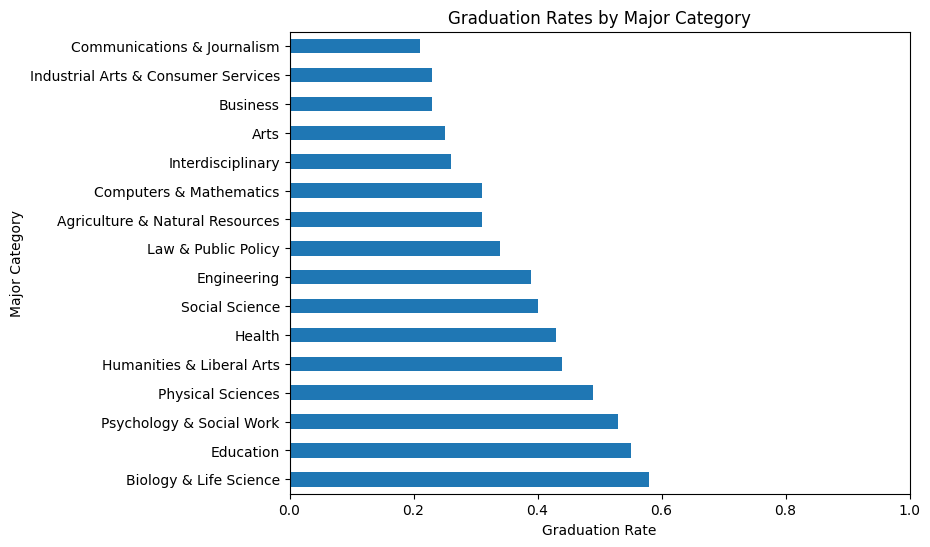

In [98]:
# Graduation rates by major category visualization and analysis - does graduation mean employment?
major_cat_groups["Grad_rate"].sort_values(ascending=False).plot(kind="barh", figsize=(8,6))
plt.title("Graduation Rates by Major Category")
plt.xlabel("Graduation Rate")
plt.ylabel("Major Category")
plt.xlim(0,1)
plt.show()

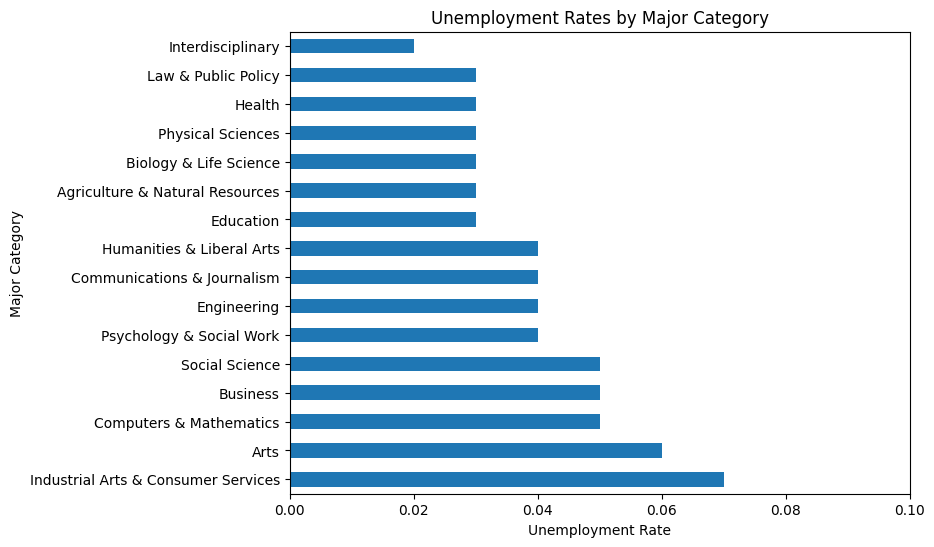

In [ ]:
# Does graduation mean employment? Let's look at the employment rate by major category and see if it correlates with graduation rates.
major_cat_groups["Graduation_Employment_rate"] = 1 - major_cat_groups["Grad_unemployment_rate"]
major_cat_groups["Nongraduation_Employment_rate"] = 1 - major_cat_groups["Nongrad_unemployment_rate"]
major_cat_groups["Grad_NongradEmployment_rate"] = (major_cat_groups["Graduation_Employment_rate"] - major_cat_groups["Nongraduation_Employment_rate"])
#major_cat_groups["Grad_NongradEmployment_rate"].sort_values(ascending=False).plot(kind="barh", figsize=(8,6))
temp = major_cat_groups[['Grad_unemployment_rate', 'Grad_rate']].sort_values('Grad_unemployment_rate', ascending=False)
temp_melt = temp.reset_index().melt(id_vars='Major_category', value_vars=['Grad_unemployment_rate', 'Grad_rate'], var_name='Metric', value_name='Rate')
sns.barplot(data=temp_melt, y='Major_category', x='Rate', hue='Metric', orient='h', figsize=(8,6))
plt.title("Unemployment and Graduation Rates by Major Category")
plt.xlabel("Unemployment Rate")
plt.ylabel("Major Category")
plt.xlim(0,0.1)
plt.show()

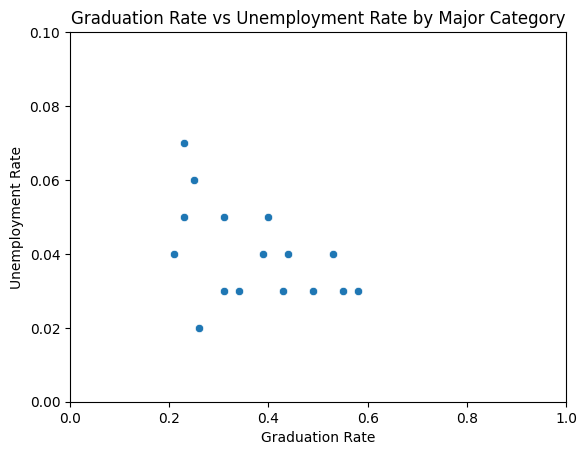

In [100]:
# Scatter plot of graduation rate and difference of employment rate between graduates and non graduates by major category
sns.scatterplot(data=major_cat_groups, x="Grad_rate", y="Grad_unemployment_rate")
plt.title("Graduation Rate vs Unemployment Rate by Major Category")
plt.xlabel("Graduation Rate")
plt.ylabel("Unemployment Rate")
plt.xlim(0,1)
plt.ylim(0,0.1)
plt.show()

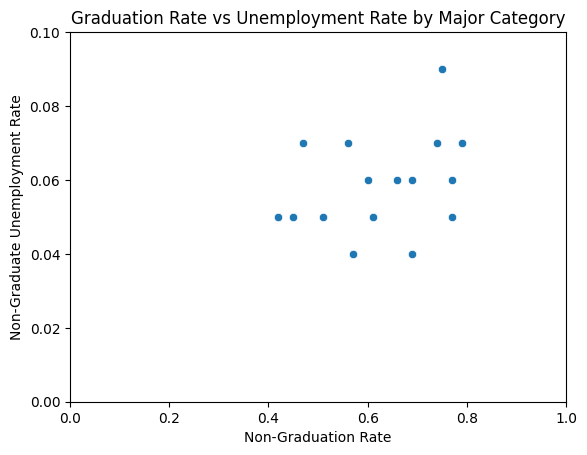

In [101]:
major_cat_groups["Nongrad_rate"] = 1 - major_cat_groups["Grad_rate"]
sns.scatterplot(data=major_cat_groups, x="Nongrad_rate", y="Nongrad_unemployment_rate")
plt.title("Graduation Rate vs Unemployment Rate by Major Category")
plt.xlabel("Non-Graduation Rate")
plt.ylabel("Non-Graduate Unemployment Rate")
plt.xlim(0,1)
plt.ylim(0,0.1)
plt.show()

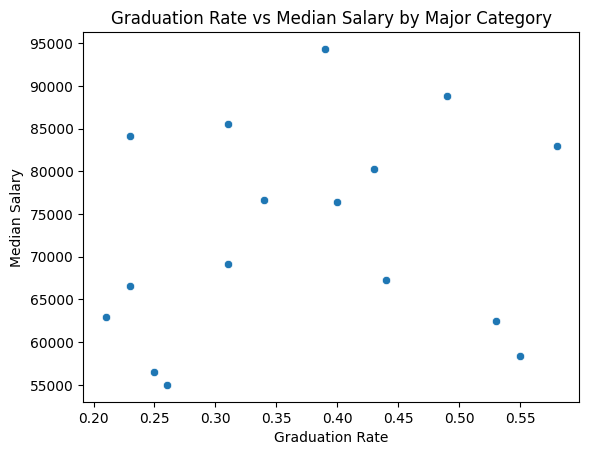

In [102]:
# How does salary change with graduation rates by major category?
sns.scatterplot(data=major_cat_groups, x="Grad_rate", y="Grad_median")
plt.title("Graduation Rate vs Median Salary by Major Category")
plt.xlabel("Graduation Rate")
plt.ylabel("Median Salary")
plt.show()

In [103]:
# unique list of values from index colummn
major_cat_groups.index.unique()

Index(['Agriculture & Natural Resources', 'Arts', 'Biology & Life Science',
       'Business', 'Communications & Journalism', 'Computers & Mathematics',
       'Education', 'Engineering', 'Health', 'Humanities & Liberal Arts',
       'Industrial Arts & Consumer Services', 'Interdisciplinary',
       'Law & Public Policy', 'Physical Sciences', 'Psychology & Social Work',
       'Social Science'],
      dtype='str', name='Major_category')

In [104]:
category_map = {
    # Science
    'Agriculture & Natural Resources': 'Science',
    'Biology & Life Science': 'Science',
    'Computers & Mathematics': 'Science',
    'Engineering': 'Science',
    'Health': 'Science',
    'Physical Sciences': 'Science',
    'Industrial Arts & Consumer Services': 'Science',

    # Arts / Humanities
    'Arts': 'Arts/Humanities',
    'Business': 'Arts/Humanities',
    'Communications & Journalism': 'Arts/Humanities',
    'Education': 'Arts/Humanities',
    'Humanities & Liberal Arts': 'Arts/Humanities',
    'Law & Public Policy': 'Arts/Humanities',
    'Psychology & Social Work': 'Arts/Humanities',
    'Social Science': 'Arts/Humanities',

    # Optional (choose one depending on your preference)
    'Interdisciplinary': 'Arts/Humanities'  # or 'Science'
}

major_cat_groups['Major_group'] = major_cat_groups.index.map(category_map)

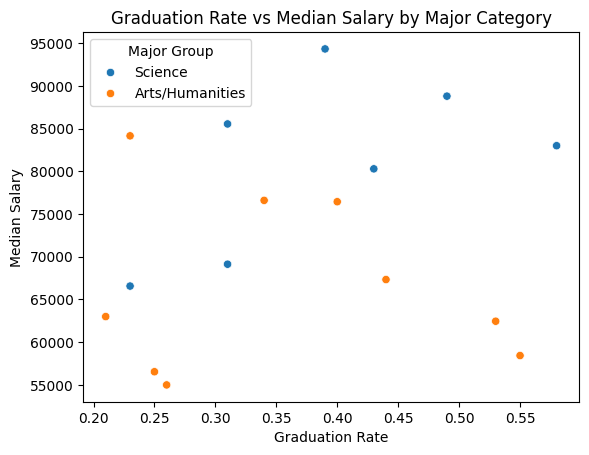

In [105]:
sns.scatterplot(data=major_cat_groups, x="Grad_rate", y="Grad_median", hue="Major_group")
plt.title("Graduation Rate vs Median Salary by Major Category")
plt.xlabel("Graduation Rate")
plt.ylabel("Median Salary")
plt.legend(title="Major Group")
plt.savefig("grad_rate_vs_median_salary_by_major_category.png", dpi=300, bbox_inches='tight')
plt.show()